# Testing the Waveform Generator

This noteboook will serve as a quick way of testing if the WaveformModule for 1PAT1R is consistently passing what it should be to the amplitude, summation and trajectory modules.

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

In [6]:
# --- Define Parameters ---
m1 = 1e6      # primary mass [solar masses]
m2 = 10       # secondary mass [solar masses]
chi1  = 1e-5
a = chi1      # primary spin chi1 (dimensionless)
p0 = 9.0      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.1 # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [7]:

# --- Generate waveform ---
WF1PAT1R = Waveform1PAT1R()
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)

h1PAT1Rzeropaamps = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T, zero_PA_amps_only=True)
h1PAT1Rnoprimary = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T, evolve_primary=False)


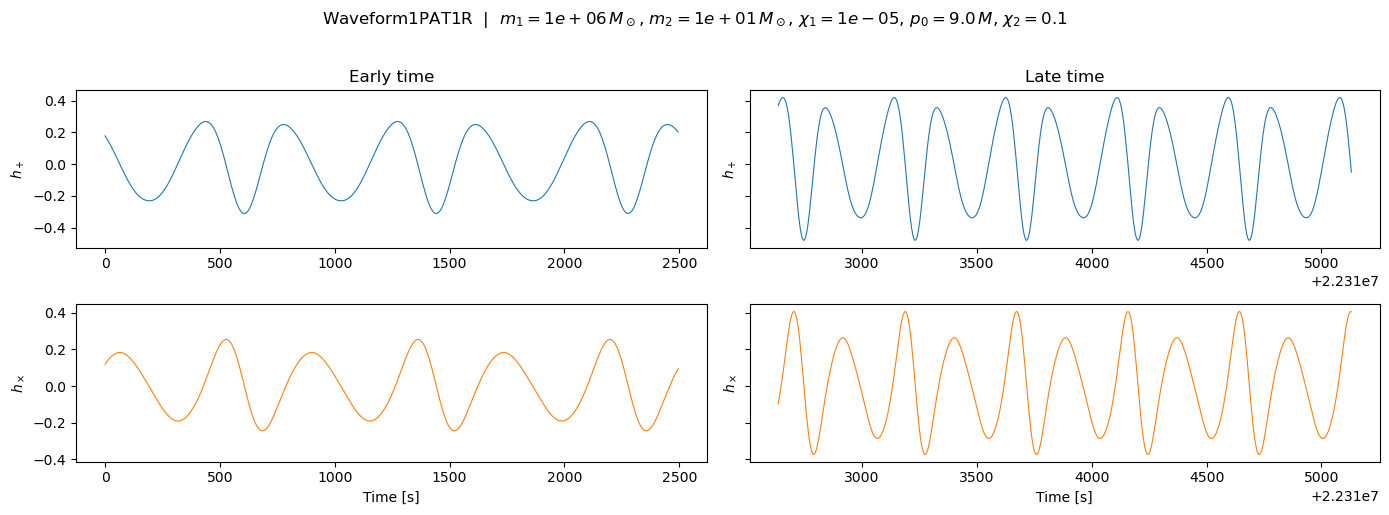

In [8]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# Number of cycles to show at each end
n_show = 500

# --- Plot: early vs late time ---
fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

title = (
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

for col, (slc, label) in enumerate([
    (slice(None, n_show),  "Early time"),
    (slice(-n_show, None), "Late time"),
]):
    axes[0, col].plot(t1PA[slc], h1PAT1R.real[slc], lw=0.8)
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel(r"$h_+$")

    axes[1, col].plot(t1PA[slc], -h1PAT1R.imag[slc], lw=0.8, color="C1")
    axes[1, col].set_ylabel(r"$h_\times$")
    axes[1, col].set_xlabel("Time [s]")

fig.suptitle(title, y=1.02)
plt.tight_layout()
plt.show()

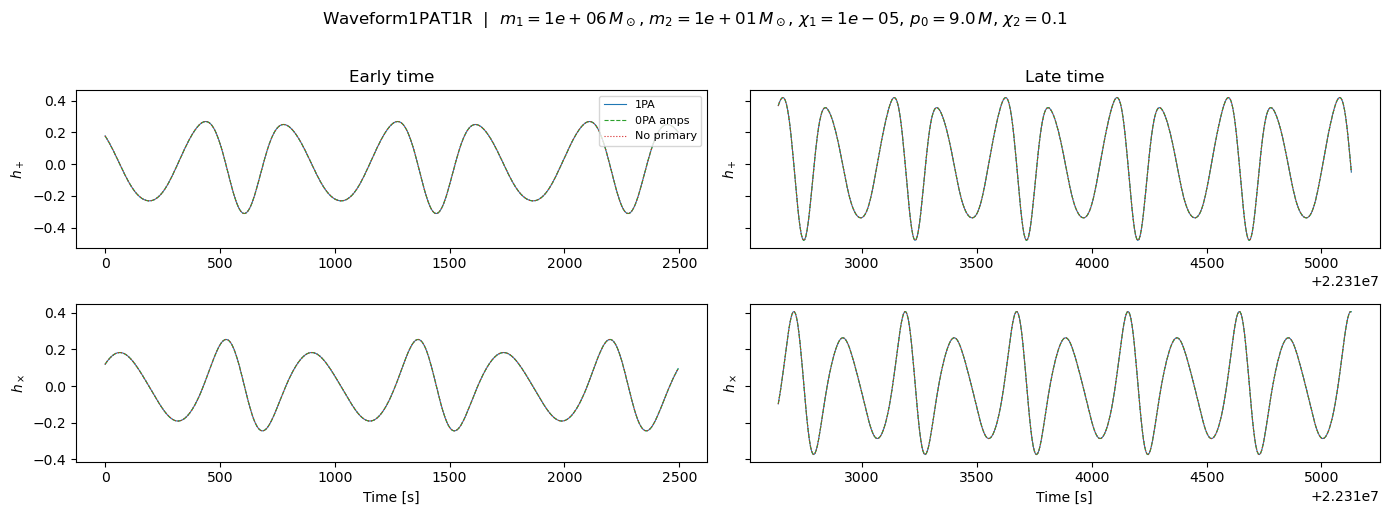

In [9]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# Number of cycles to show at each end
n_show = 500

# --- Plot: early vs late time ---
fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

title = (
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

for col, (slc, label) in enumerate([
    (slice(None, n_show),  "Early time"),
    (slice(-n_show, None), "Late time"),
]):
    axes[0, col].plot(t1PA[slc], h1PAT1R.real[slc],             lw=0.8, color="C0", label="1PA")
    axes[0, col].plot(t1PA[slc], h1PAT1Rzeropaamps.real[slc],   lw=0.8, color="C2", label="0PA amps", ls="--")
    axes[0, col].plot(t1PA[slc], h1PAT1Rnoprimary.real[slc],    lw=0.8, color="C3", label="No primary", ls=":")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel(r"$h_+$")

    axes[1, col].plot(t1PA[slc], -h1PAT1R.imag[slc],            lw=0.8, color="C0", label="1PA")
    axes[1, col].plot(t1PA[slc], -h1PAT1Rzeropaamps.imag[slc],  lw=0.8, color="C2", label="0PA amps", ls="--")
    axes[1, col].plot(t1PA[slc], -h1PAT1Rnoprimary.imag[slc],   lw=0.8, color="C3", label="No primary", ls=":")
    axes[1, col].set_ylabel(r"$h_\times$")
    axes[1, col].set_xlabel("Time [s]")

# Add legend once, on the top-left panel
axes[0, 0].legend(fontsize=8, loc="upper right")

fig.suptitle(title, y=1.02)
plt.tight_layout()
plt.show()

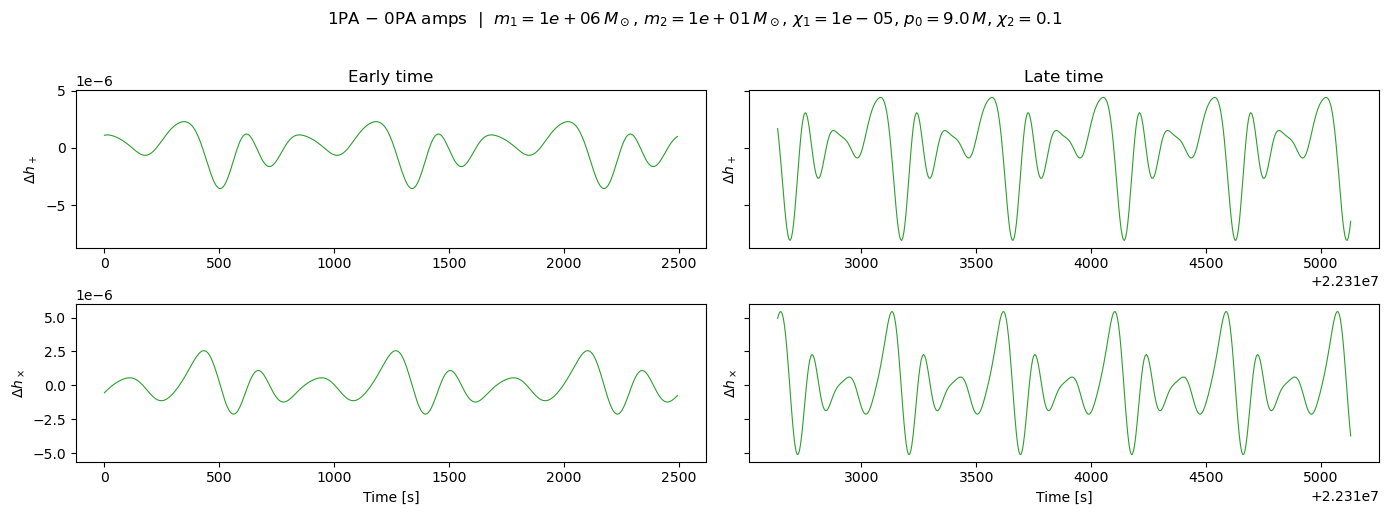

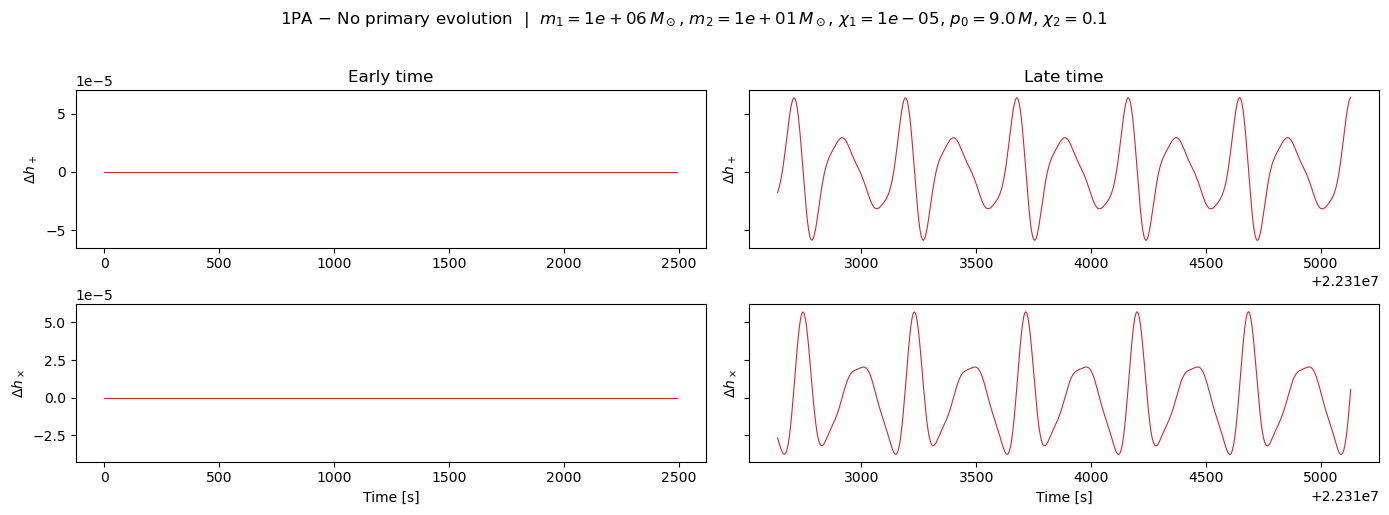

In [10]:
diffs = [
    (h1PAT1R - h1PAT1Rzeropaamps,  "1PA $-$ 0PA amps",          "C2"),
    (h1PAT1R - h1PAT1Rnoprimary,   "1PA $-$ No primary evolution", "C3"),
]

for diff, diff_label, color in diffs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

    title = (
        rf"{diff_label}  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
        rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
    )

    for col, (slc, label) in enumerate([
        (slice(None, n_show),  "Early time"),
        (slice(-n_show, None), "Late time"),
    ]):
        axes[0, col].plot(t1PA[slc], diff.real[slc],  lw=0.8, color=color)
        axes[0, col].set_title(label)
        axes[0, col].set_ylabel(r"$\Delta h_+$")

        axes[1, col].plot(t1PA[slc], -diff.imag[slc], lw=0.8, color=color)
        axes[1, col].set_ylabel(r"$\Delta h_\times$")
        axes[1, col].set_xlabel("Time [s]")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

In [11]:
# --- Generate comparison waveform ---
WFKerr0PA = FastKerrEccentricEquatorialFlux()
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)

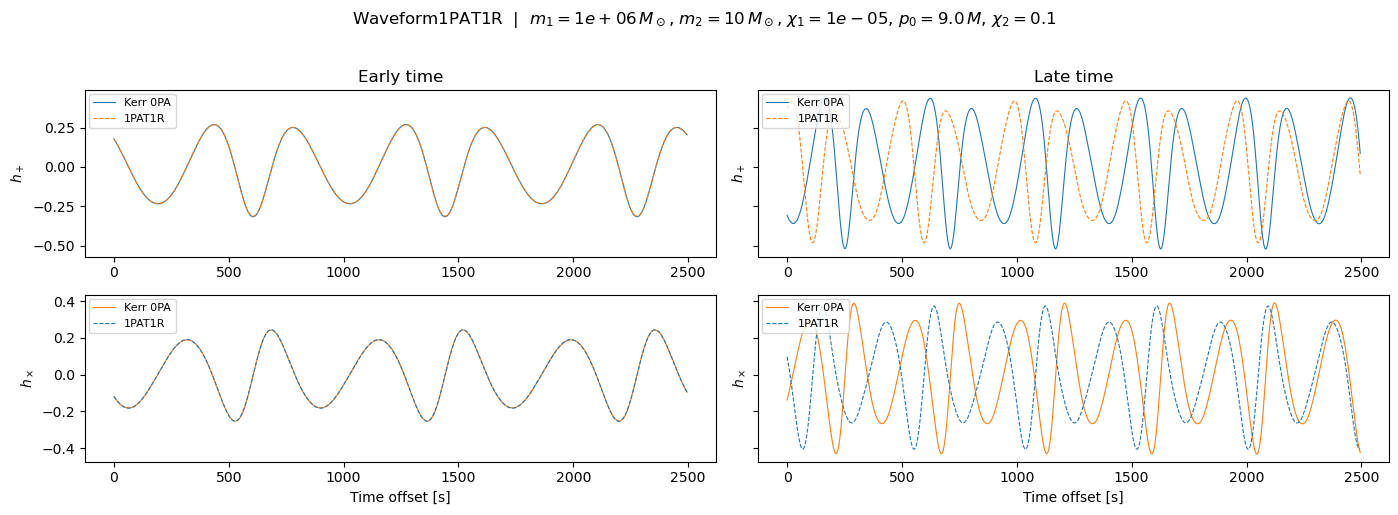

In [12]:
tKerr = np.arange(len(hKerr)) * dt  # time array in seconds

# Number of samples to show at each end
n_show = 500

# --- Plot: early vs late time ---
fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

title = (
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

for col, (label, slc_kerr, slc_1pa) in enumerate([
    ("Early time", slice(None, n_show),  slice(None, n_show)),
    ("Late time",  slice(-n_show, None), slice(-n_show, None)),
]):
    tK = tKerr[slc_kerr];  tK = tK - tK[0]
    t1 = t1PA[slc_1pa];    t1 = t1 - t1[0]

    axes[0, col].plot(tK, hKerr.real[slc_kerr], lw=0.8, label="Kerr 0PA")
    axes[0, col].plot(t1, h1PAT1R.real[slc_1pa], lw=0.8, ls="--", color="C1", label="1PAT1R")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel(r"$h_+$")
    axes[0, col].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, 1),
                        borderaxespad=0.3)

    axes[1, col].plot(tK, hKerr.imag[slc_kerr], lw=0.8, color="C1", label="Kerr 0PA")
    axes[1, col].plot(t1, h1PAT1R.imag[slc_1pa], lw=0.8, ls="--", color="C0", label="1PAT1R")
    axes[1, col].set_ylabel(r"$h_\times$")
    axes[1, col].set_xlabel("Time offset [s]")
    axes[1, col].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, 1),
                        borderaxespad=0.3)

fig.suptitle(title, y=1.02)
plt.tight_layout()
plt.show()
